## Graphs Processing

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
# task = "LinReg"
task = "BinClass"
path = f"../scripts/results/{task}_all_ranks_all_batch_20_by_2.csv"

In [48]:
df_bin = pd.read_csv(path)
# df_1 = pd.read_csv(f'results/one_more_BinClass_1_3.csv')
# df_1  = df_1.query("optimizer != 'Torch_Adagrad'")
# df_2 = pd.read_csv(f'results/one_modeBinClass_4_5.csv')

# df_3 = pd.read_csv(f'results/LinReg_ranks_1_3_diff_tracking_20_by_2.csv')
# df_3  = df_3.query("optimizer != 'Torch_Adagrad'")
# df_4 = pd.read_csv(f'results/LinReg_ranks_4_5_diff_tracking_20_by_2.csv')



# df_bin = pd.concat([df_1, df_2])
# df_linreg = pd.concat([df_3, df_4])

df_bin.head(15)


,Unnamed: 0,epoch,optimizer,lr,loss,accuracy,mode,rank,eps,X_type,avg_epoch_time,epoch_time,batch_size,data_seed
0,0,0,AdaGramPS rank 2,0.1,0.676284,0.533333,test,2.0,0.1,X true,0.000000,0.000000,1,10.0
1,1,0,AdaGramPS rank 2,0.1,0.666769,0.550000,train,2.0,0.1,X true,0.000000,0.000000,1,10.0
2,2,1,AdaGramPS rank 2,0.1,0.403735,0.833333,test,2.0,0.1,X true,1.723045,1.723045,1,NaN
3,3,1,AdaGramPS rank 2,0.1,0.302404,0.900000,train,2.0,0.1,X true,1.723045,1.723045,1,NaN
4,4,2,AdaGramPS rank 2,0.1,0.370757,0.850000,test,2.0,0.1,X true,1.773751,1.824457,1,NaN
5,5,2,AdaGramPS rank 2,0.1,0.245762,0.904167,train,2.0,0.1,X true,1.773751,1.824457,1,NaN
6,6,3,AdaGramPS rank 2,0.1,0.340292,0.850000,test,2.0,0.1,X true,1.815016,1.896548,1,NaN
7,7,3,AdaGramPS rank 2,0.1,0.217763,0.916667,train,2.0,0.1,X true,1.815016,1.896548,1,NaN
8,8,4,AdaGramPS rank 2,0.1,0.328611,0.866667,test,2.0,0.1,X true,1.816096,1.819337,1,NaN
9,9,4,AdaGramPS rank 2,0.1,0.197270,0.925000,train,2.0,0.1,X true,1.816096,1.819337,1,NaN


<Figure size 1500x1000 with 0 Axes>

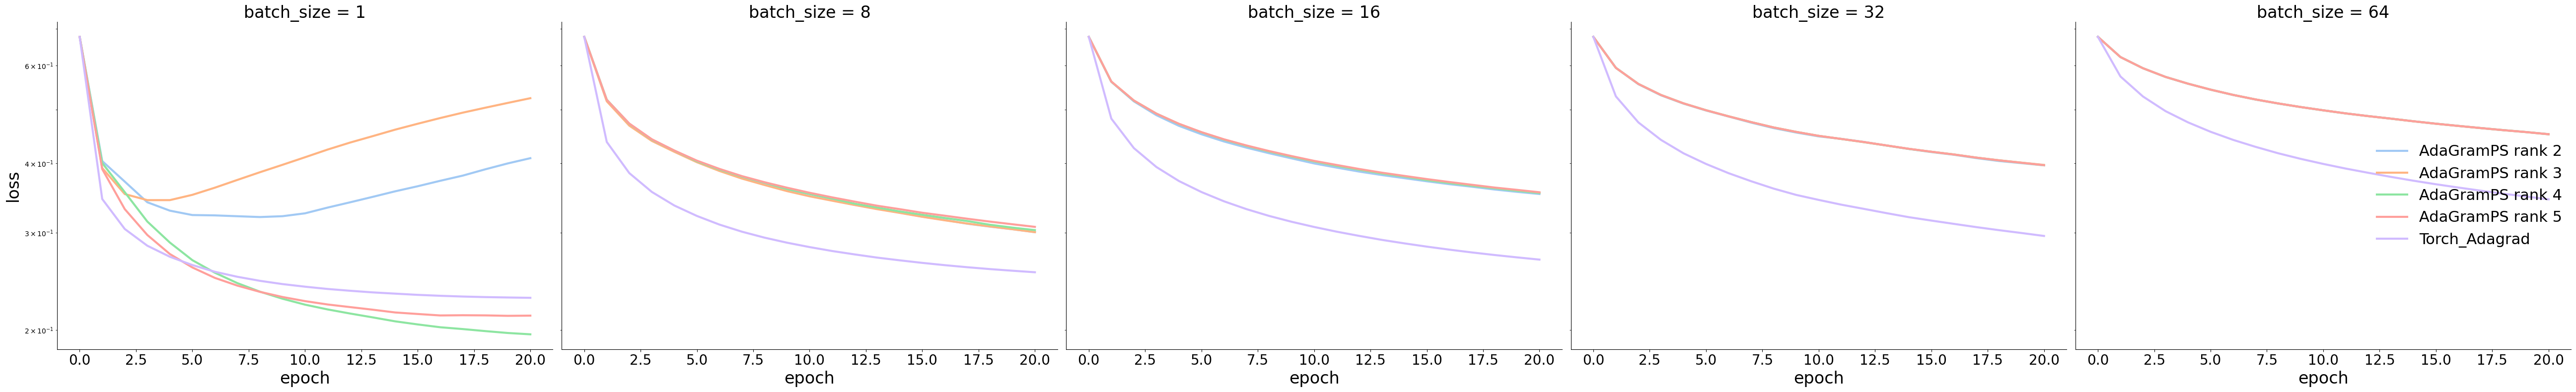

In [49]:
import os
# torch_ada = df_bin.query("optimizer == 'AdaGramPS rank 4' and mode == 'test' and epoch < 20")
dir = "plots"

plt.figure(figsize=(15, 10))
grid = sns.FacetGrid(
    data=df_bin.query('mode == "test" and optimizer != "AdaGramFR_svd"'),
    # "optimizer != 'AdaGramFR_s'vd rank 2' and optimizer != 'AdaGramFR_svd rank 3'and optimizer != 'AdaGramFR_svd rank 5'"),
    col='batch_size',
    height=8,
    aspect=1.2,
    sharey=True,
)


grid.map_dataframe(
    sns.lineplot,
    
    x='epoch',
    # y='avg_epoch_time',
    y='loss',
    # style='',
    hue='optimizer',
    palette='pastel',
    linewidth=3
)

# Set bigger font size for legend title and legend text
grid.add_legend(fontsize=22)

# grid.fig.suptitle(f'LinReg(20, 2)', 
#                   fontsize=24,)

# grid.fig.suptitle(f'BinClassification({in_dims[0]}, {out_dims[0]})', 
#                   fontsize=24, y=1.02)

# Set bigger font size for axis labels
for ax in grid.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel(ax.get_xlabel(), fontsize=24)
    ax.set_ylabel(ax.get_ylabel(), fontsize=24)
    ax.tick_params(axis='x', which='major', labelsize=20)
    ax.tick_params(axis='y', which='major', labelsize=20)
    

grid.set_titles(col_template="batch_size = {col_name}")
for ax in grid.axes.flat:
    ax.set_title(ax.get_title(), fontsize=24)  # Explicitly set desired fontsize

output_path = os.path.join(dir, f'{task}_batches.pdf')
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()


NameError: name 'in_dims' is not defined

<Figure size 1500x800 with 0 Axes>

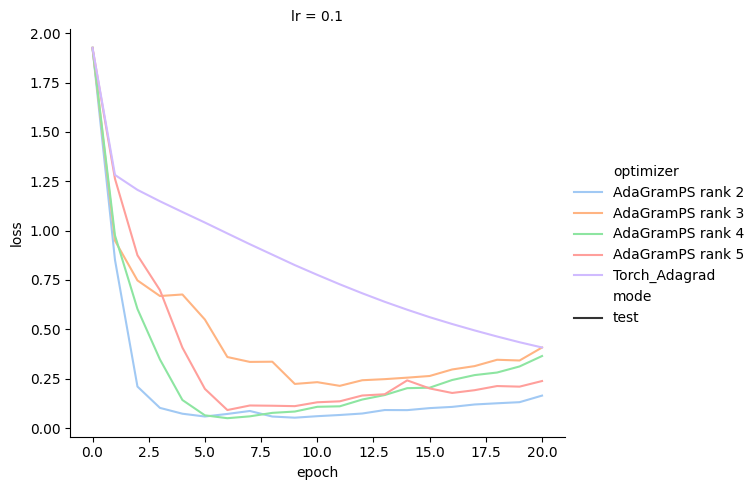

In [11]:
plt.figure(figsize=(15, 8))
grid = sns.FacetGrid(
    data=df_bin.query("mode == 'test' and (optimizer.str.contains('AdaGramPS') or optimizer == 'Torch_Adagrad')", engine="python"),
    # "optimizer != 'AdaGramFR_s'vd rank 2' and optimizer != 'AdaGramFR_svd rank 3'and optimizer != 'AdaGramFR_svd rank 5'"),
    col='lr',
    height=5,
    aspect=1.2,
    sharey=True
)

grid.map_dataframe(
    sns.lineplot,
    
    x='epoch',
    # y='avg_epoch_time',
    y='loss',
    style='mode',
    hue='optimizer',
    palette='pastel',
    linewidth=1.5
)

# Set bigger font size for legend title and legend text
grid.add_legend()

grid.fig.suptitle(f'BinClassification({in_dims[0]}, {out_dims[0]})', 
                  fontsize=24, y=1.02)

# grid.fig.suptitle(f'BinClassification({in_dims[0]}, {out_dims[0]})', 
#                   fontsize=24, y=1.02)

# Set bigger font size for axis labels
for ax in grid.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)

grid.set_titles(col_template="lr = {col_name}", fontsize=20)

plt.tight_layout()
plt.show()

C:\Users\tanya\AppData\Local\Temp\ipykernel_25876\1652104739.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_accuracies = df_test.groupby('optimizer').apply(
C:\Users\tanya\AppData\Local\Temp\ipykernel_25876\1652104739.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_losses = df_test.groupby('optimizer').apply(
C:\Users\tanya\AppData\Local\Temp\ipykernel_25876\1652104739.py:49: UserWarnin

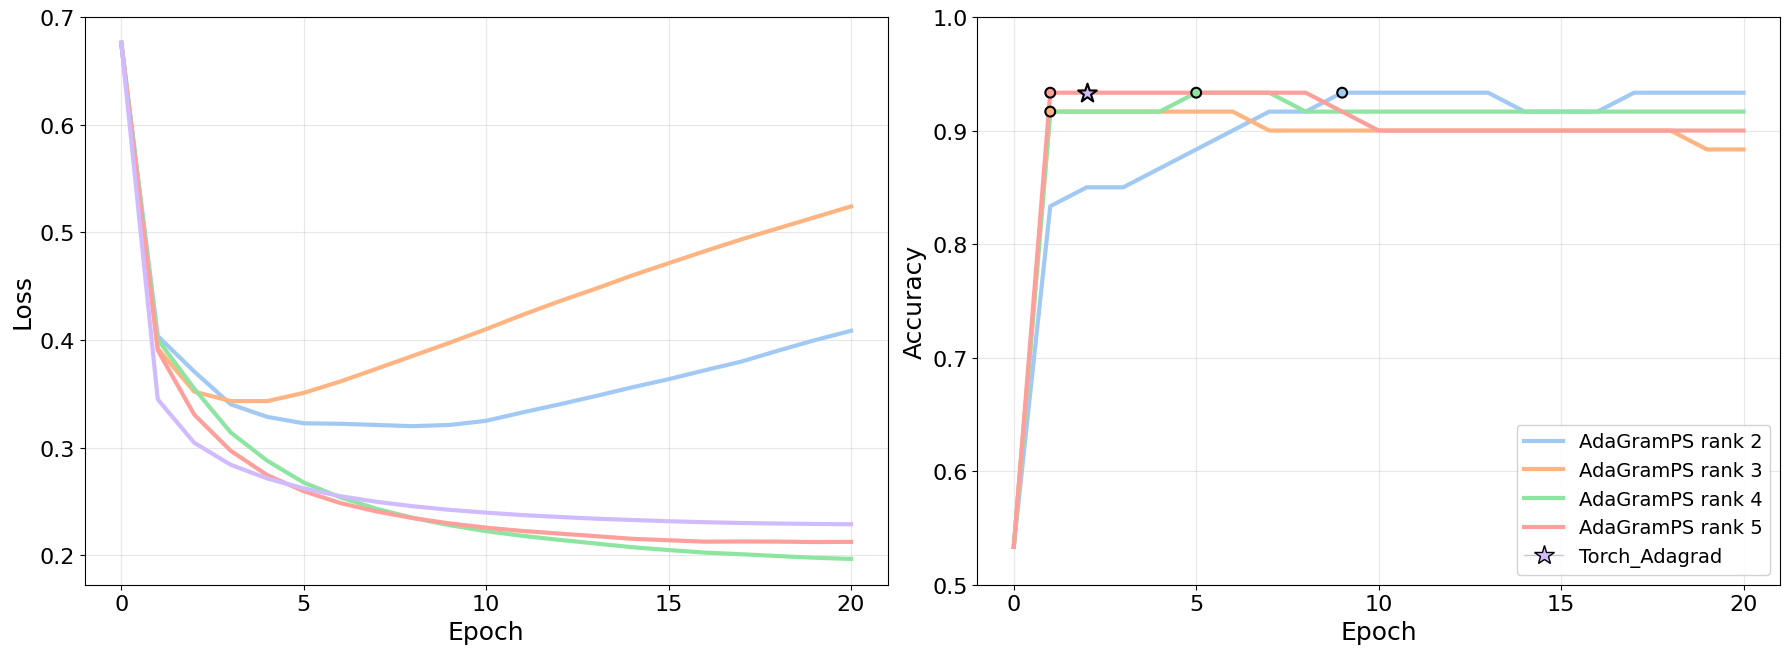

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
import os

dir = './plots'

# Your existing data preparation code...
df_test = df_bin[df_bin['mode'] == 'test']
best_accuracies = df_test.groupby('optimizer').apply(
    lambda g: g.loc[g['accuracy'].idxmax()]
).reset_index(drop=True)

best_losses = df_test.groupby('optimizer').apply(
    lambda g: g.loc[g['loss'].idxmin()]
).reset_index(drop=True)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

# Color mapping
optimizers = df_test['optimizer'].unique()
palette = sns.color_palette('pastel', len(optimizers))
color_map = {opt: color for opt, color in zip(optimizers, palette)}

# Plot loss over epochs (left subplot)
sns.lineplot(data=df_test, x='epoch', y='loss', hue='optimizer', linewidth=3,
             markers=True, legend=False, palette=color_map, ax=axes[0])

# axes[0].set_title('Loss over Epochs', fontsize=22)
axes[0].set_xlabel('Epoch', fontsize=18)
axes[0].set_ylabel('Loss', fontsize=18)
# axes[0].set_yscale('log')  # Keep log scale for loss
axes[0].grid(True, alpha=0.3)

# Plot accuracy over epochs (right subplot)
sns.lineplot(data=df_test.query("optimizer != 'Torch_Adagrad'"), x='epoch', y='accuracy', hue='optimizer', linewidth=3,
             markers=True, palette=color_map, ax=axes[1])

# Add scatter points
sns.scatterplot(data=best_accuracies.query("optimizer != 'Torch_Adagrad'"), x='epoch', y='accuracy', hue='optimizer', 
                s=50, edgecolor='black', linewidth=1.5, legend=False, zorder=5, palette=color_map, ax=axes[1])

# Add star marker for Torch_Adagrad
torch_adagrad_best_row = best_accuracies[best_accuracies['optimizer'] == 'Torch_Adagrad']
if not torch_adagrad_best_row.empty:
    torch_adagrad_best = torch_adagrad_best_row.iloc[0]
    axes[1].scatter(torch_adagrad_best['epoch'], torch_adagrad_best['accuracy'], 
                   s=200, marker='*', c=color_map['Torch_Adagrad'], edgecolors='black', linewidths=1.5, 
                   zorder=10)

# axes[1].set_title('Accuracy over Epochs', fontsize=22)
axes[1].set_xlabel('Epoch', fontsize=18)
axes[1].set_ylabel('Accuracy', fontsize=18)

# FIX 1: Remove log scale from accuracy plot
# axes[1].set_yscale('log')  # Comment this out or remove it

# FIX 2: Set better y-axis limits for accuracy
axes[1].set_ylim(0.5, 1.0)  # Adjust range to show meaningful differences

# FIX 3: Improve tick formatting
for ax in axes:
    ax.tick_params(axis='x', which='major', labelsize=16)
    ax.tick_params(axis='y', which='major', labelsize=16)
    
# FIX 4: Set specific tick locations for better readability
axes[0].set_xticks(range(0, 21, 5))  # Ticks every 5 epochs
axes[1].set_xticks(range(0, 21, 5))
axes[1].set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])  # Clear accuracy intervals

# Legend with better positioning
handles, labels = axes[1].get_legend_handles_labels()
star_handle = Line2D([0], [0], marker='*', color=color_map['Torch_Adagrad'], label='Torch_Adagrad',
                      markeredgecolor='black', markersize=15, linewidth=1)
handles.append(star_handle)
labels.append('Torch_Adagrad')

# FIX 5: Better legend positioning
axes[1].legend(handles=handles, labels=labels, fontsize=14, 
               loc='lower right', framealpha=0.9)  # Adjust location as needed

axes[1].grid(True, alpha=0.3)
output_path = os.path.join(dir, 'psi_bin_classification.pdf')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()



NameError: name 'df_bin' is not defined

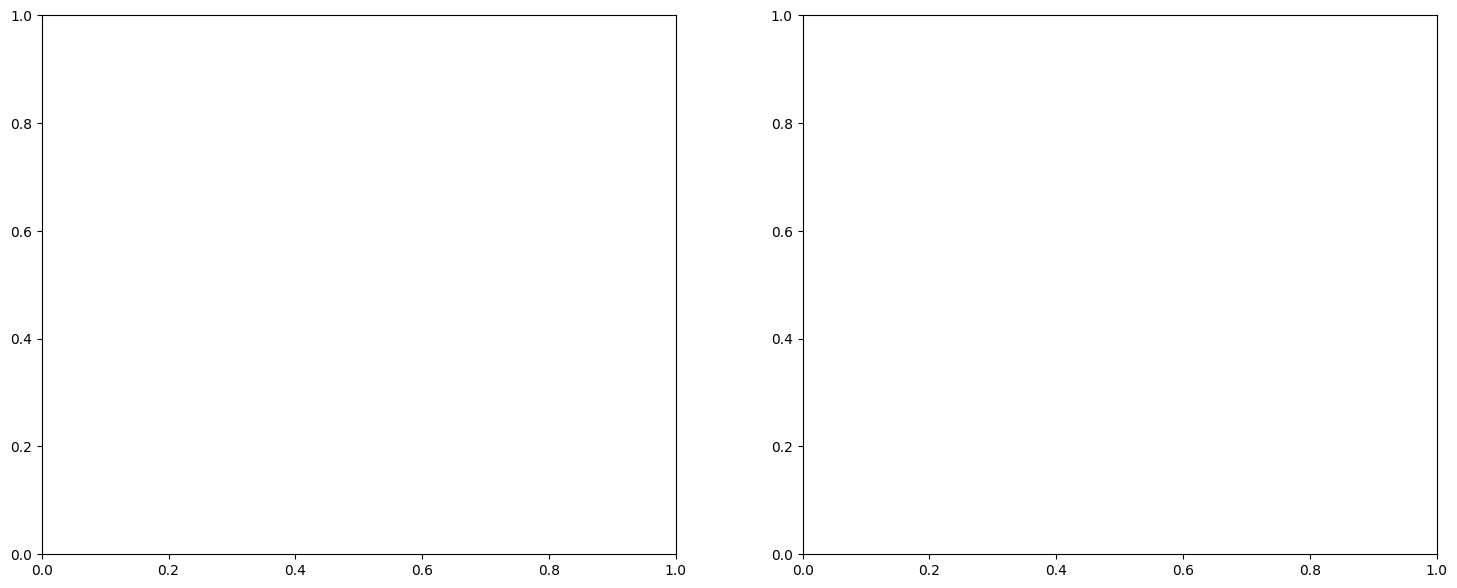

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your DataFrame with 'loss' and 'accuracy' columns
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

# Plot loss over epochs
sns.lineplot(
    data=df_bin.query('mode == "test" and rank == 4'), 
    x='epoch', y='loss', hue='optimizer', 
    palette='pastel', linewidth=1.5, ax=axes[0]
)
# axes[0].set_title('Loss over Epochs', fontsize=20)
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch', fontsize=16)
axes[0].set_ylabel('Loss', fontsize=16)

# Plot accuracy over epochs
sns.lineplot(
    data=df_bin.query('mode == "test" and rank == 4'),
    x='epoch', y='accuracy', hue='optimizer', 
    palette='pastel', linewidth=1.5, ax=axes[1]
)
# axes[1].set_title('Accuracy over Epochs', fontsize=20)
axes[1].set_xlabel('Epoch', fontsize=16)
axes[1].set_ylabel('Accuracy', fontsize=16)

# Adjust legend to only appear once on the right plot
axes[1].legend(title='Optimizer', fontsize=12, title_fontsize=14)

# Set main title
plt.suptitle('Binary Classification (20, 2)', fontsize=24)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
plt.savefig('binclassification_plots.pdf', format='pdf', bbox_inches='tight')

plt.show()


## Matrix G evolution

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import re

# Directory containing G matrix files
matrix_dir = "../scripts/matrix_G/"
matrix_out_dir = "../scripts/matrix_G_pngs/"

def numerical_key(filename):
    # Extract numbers as integers; returns (inf,) if no number is found
    numbers = re.findall(r'\d+', os.path.basename(filename))
    return tuple(map(int, numbers)) if numbers else (float('inf'),)

# Find all .pt files in the directory
file_pattern = os.path.join(matrix_dir, "*.pt")
files = glob.glob(file_pattern)
files.sort(key=numerical_key)  # Sort for chronological order

print(f"Found {len(files)} G matrix files to process...")

# Process each file
for filename in files[:100]:
    try:
        # Extract just the filename without path for display
        base_filename = os.path.basename(filename)
        print(f"Processing: {base_filename}")
        
        # Load G matrix
        G_matrix = torch.load(filename, map_location='cpu')
        
        # Convert to numpy array for plotting
        G_numpy = G_matrix.numpy()
        
        # Create heatmap
        plt.figure(figsize=(10, 8))
        plt.imshow(G_numpy, cmap='viridis', aspect='auto')
        plt.colorbar(label='Values')
        
        # Extract epoch info from filename for better title
        if 'epoch_' and 'batch_' in base_filename:
            epoch_info = base_filename.split('epoch_')[1].split('_')[0]
            batch_info = base_filename.split('batch_')[1].split('_')[0]

            title = f'Heatmap of G Matrix - Epoch {epoch_info}, step {batch_info}'
        else:
            title = f'Heatmap of G Matrix - {base_filename}'
        
        plt.title(title)
        plt.xlabel('Columns')
        plt.ylabel('Rows')
        
        # Create output filename (replace .pt with .png)
        output_filename = base_filename.replace('.pt', '.png')
        output_path = os.path.join(matrix_out_dir, output_filename)
        
        # Save the plot as PNG
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()  # Close the figure to free memory
        
        print(f"Saved: {output_filename}")
        
    except Exception as e:
        print(f"Error processing {base_filename}: {str(e)}")
        continue

print("Processing complete!")


Found 401 G matrix files to process...
Processing: G_matrix_epoch_0_adagram_task_BinClass.pt
Saved: G_matrix_epoch_0_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_0_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_0_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_1_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_1_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_2_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_2_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_3_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_3_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_4_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_4_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_5_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_5_adagram_task_BinClass.png
Processing: G_matrix_epoch_1_batch_6_adagram_task_BinClass.pt
Saved: G_matrix_epoch_1_batch_6_adagram_task_BinClass.png
Processing: G_mat

In [3]:
from PIL import Image
import glob
import os


def create_gif_from_pngs(pattern="*.png", output="output.gif", directory=".", duration=500, optimize=True):
    """Create GIF from PNG files matching the pattern in a specific directory"""
    
    # Construct full pattern with directory path
    full_pattern = os.path.join(directory, pattern)
    files = glob.glob(full_pattern)
    print(f"Looking in: {full_pattern}")
    print(f"Found files: {files}")
    

    files.sort(key=numerical_key)
    
    if not files:
        print(f"No files found matching pattern: {full_pattern}")
        return
    
    # Load images
    images = [Image.open(f) for f in files]
    
    # Create output path in the same directory
    output_path = os.path.join(directory, output)
    
    # Create GIF
    images[0].save(
        output_path,
        save_all=True,
        append_images=images[1:],
        duration=duration,
        loop=0,
        optimize=optimize
    )
    
    print(f"GIF created: {output_path}")
    print(f"Frames: {len(images)}")

# Usage for your specific case
matrix_dir = "../scripts/matrix_G_pngs/"
create_gif_from_pngs("G_matrix_epoch_*.png", "matrix_evolution.gif", matrix_dir, duration=800)
create_gif_from_pngs("*.png", "all_matrices.gif", matrix_dir)


Looking in: ../scripts/matrix_G_pngs/G_matrix_epoch_*.png
Found files: ['../scripts/matrix_G_pngs\\G_matrix_epoch_0_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_0_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_10_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_11_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_12_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_13_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_14_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_15_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_16_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_17_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_batch_18_adagram_task_BinClass.png', '../scripts/matrix_G_pngs\\G_matrix_epoch_1_bat

In [15]:
# df_1 = pd.read_csv('results/loggs/nosvd_adagram_logs.csv')
# df_1["method"] = ["nosvd"] * len(df_1['lr'])

# df_2 = pd.read_csv('results/loggs/svd_adagram_logs_10.csv')
# df_2["method"] = ["svd"] * len(df_2['lr'])

# df_3 = pd.read_csv('results/loggs/psi_adagram_logs.csv')
# df_3["method"] = ["psi"] * len(df_3['lr'])

df_4 = pd.read_csv('results/loggs/svd_adagram_logs_1000.csv')
df_4["method"] = ["vanila"] * len(df_4['lr'])

df = pd.concat([df_4])


In [16]:
df = df.reset_index(drop=True)

## Loggs Statistics

In [126]:
import pandas as pd
import glob
import os
import re

def extract_metadata(filename):
    # Remove directory and extension
    base = os.path.basename(filename)
    name, _ = os.path.splitext(base)
    # Match optimizer and rank (e.g., nosvd_adagram_logs_2)
    match = re.match(r'([a-zA-Z]+)_adagram_logs_(\d+)', name)
    if match:
        optimizer = match.group(1)
        rank = int(match.group(2))
    elif name == 'adagram_vanila':
        optimizer = 'vanilla'
        rank = None
    else:
        print(name)
        optimizer = 'unknown'
        rank = None
    return optimizer, rank

csv_files = glob.glob('../scripts/results/loggs/*.csv')
print(csv_files)

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    optimizer, rank = extract_metadata(file)
    df['method'] = optimizer
    df['rank'] = rank
    dfs.append(df)

df_logs = pd.concat(dfs, ignore_index=True)


['../scripts/results/loggs\\adagram_full_adagrad.csv', '../scripts/results/loggs\\adagram_logs.csv']
adagram_full_adagrad
adagram_logs


C:\Users\tanya\AppData\Local\Temp\ipykernel_3556\76817871.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_logs = pd.concat(dfs, ignore_index=True)


In [127]:
df_logs.head(10)

,step,param_id,grad_norm,grad_std,beta,lr,error_norm,rank_U,rank_V,max_U,...,max_V,min_V,U_shape_0,U_shape_1,V_shape_0,V_shape_1,method,rank,error_norm_sqrt,error_svd
0,1,0,0.296793,0.047525,0.010150,0.1,1.305431e-07,1,1,0.031038,...,3.058051,-3.058052,40,1,40,1,unknown,None,1.489215e-06,0.0
1,1,1,0.621876,0.621876,0.002454,0.1,1.215315e-07,1,1,0.034131,...,13.905581,-13.905578,2,1,2,1,unknown,None,4.173457e-07,0.0
2,2,0,0.589780,0.094440,0.002798,0.1,4.061235e-07,2,2,0.031038,...,8.018862,-8.018860,40,2,40,2,unknown,None,1.640340e-01,0.0
3,2,1,0.786835,0.786834,0.237631,0.1,5.058030e-07,2,1,0.212329,...,13.905581,-13.905578,2,2,2,2,unknown,None,5.838632e-07,0.0
4,3,0,0.417742,0.066892,0.007681,0.1,6.821674e-07,3,3,0.034629,...,8.018862,-8.018860,40,3,40,3,unknown,None,2.221021e-01,0.0
5,3,1,0.545145,0.545145,0.410979,0.1,2.143909e-07,2,1,0.212329,...,13.905581,-13.905578,2,3,2,3,unknown,None,3.910181e-06,0.0
6,4,0,0.747261,0.119657,0.003344,0.1,1.068096e-06,4,4,0.034629,...,8.018862,-8.018860,40,4,40,4,unknown,None,1.097406e-01,0.0
7,4,1,0.651999,0.651999,0.403631,0.1,2.412969e-07,2,1,0.212329,...,13.905581,-13.905578,2,4,2,4,unknown,None,2.040443e-06,0.0
8,5,0,0.318926,0.051069,0.013376,0.1,1.029970e-06,5,5,0.034629,...,8.018862,-8.018860,40,5,40,5,unknown,None,1.474491e-01,0.0
9,5,1,0.502910,0.502910,0.451078,0.1,1.533394e-07,2,1,0.212329,...,13.905581,-13.905578,2,5,2,5,unknown,None,6.497063e-07,0.0


c:\Users\tanya\mambaforge\envs\data-science-intro\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
c:\Users\tanya\mambaforge\envs\data-science-intro\Lib\site-packages\seaborn\axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)


<Figure size 1500x800 with 0 Axes>

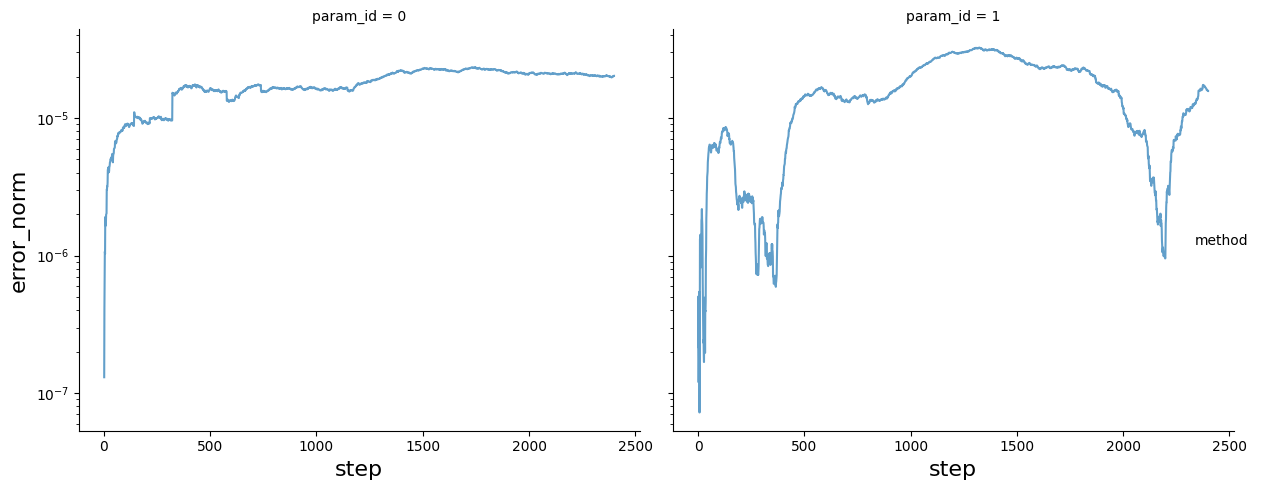

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
grid = sns.FacetGrid(
    data=df_logs,
    col='param_id',
    height=5,
    aspect=1.2,
    sharey=True
)

grid.map_dataframe(
    sns.lineplot,
    x='step',
    # y='avg_epoch_time',
    y='error_norm',
    # style='method',
    # hue='rank',
    palette='pastel',
    alpha = 0.7,
    linewidth=1.5
)

# Set bigger font size for legend title and legend text
grid.add_legend(title='method', title_fontsize='15', fontsize='12')

# grid.fig.suptitle(f'LinRegression({in_dims[0]}, {out_dims[0]})', 
#                   fontsize=24, y=1.02)

# grid.fig.suptitle(f'BinClassification({in_dims[0]}, {out_dims[0]})', 
#                   fontsize=24, y=1.02)

# Set bigger font size for axis labels
for ax in grid.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)

grid.set_titles(col_template="param_id = {col_name}", fontsize=20)

plt.tight_layout()
plt.show()